# Neural Style Transfer with Keras

This notebook demonstrates Neural Style Transfer, a technique that allows you to recompose the content of one image in the style of another. It achieves this by optimizing an image to simultaneously match the content representation of a 'content' image and the style representation of a 'style reference' image, as learned by a pre-trained convolutional neural network (VGG19 in this case).

In [1]:
from tensorflow import keras

In [2]:
base_image_path = keras.utils.get_file(
"sf.jpg", origin="https://img-datasets.s3.amazonaws.com/sf.jpg")

style_reference_image_path = keras.utils.get_file(
"starry_night.jpg",
origin="https://img-datasets.s3.amazonaws.com/starry_night.jpg")

original_width, original_height = keras.utils.load_img(base_image_path).size
img_height = 400
img_width = round(original_width * img_height / original_height)

575046/575046 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
943128/943128 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
import matplotlib.pyplot as plt

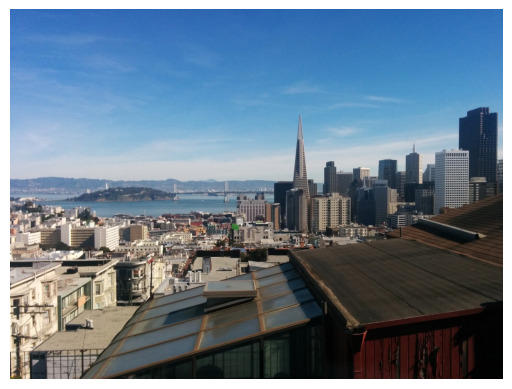

In [6]:
plt.axis("off")
plt.imshow(keras.utils.load_img(base_image_path))

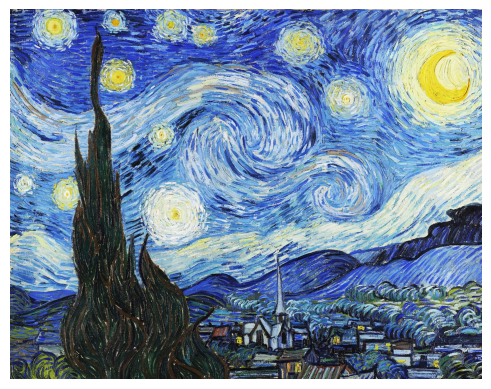

In [7]:
plt.axis("off")
plt.imshow(keras.utils.load_img(style_reference_image_path))

In [8]:
#auxillary functions
import numpy as np

def preprocess_image(image_path):
  img = keras.utils.load_img(
      image_path, target_size=(img_height, img_width))
  img = keras.utils.img_to_array(img)
  img = np.expand_dims(img, axis=0)
  img = keras.applications.vgg19.preprocess_input(img)
  return img

def deprocess_image(img):
  img = img.reshape((img_height, img_width, 3))
  img[:, :, 0] += 103.939
  img[:, :, 1] += 116.779
  img[:, :, 2] += 123.68
  img = img[:, :, ::-1]
  img = np.clip(img, 0, 255).astype("uint8")
  return img

In [9]:
#using pre-trained VGG model to create a feature extractor
model = keras.applications.vgg19.VGG19(weights="imagenet", include_top=False)

outputs_dict = dict([(layer.name, layer.output) for layer in model.layers])
feature_extractor = keras.Model(inputs=model.inputs, outputs=outputs_dict)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
#content loss
def content_loss(base_img, combination_img):
  return tf.reduce_sum(tf.square(combination_img - base_img))

#style loss
#Gram Matrix:a map of correlations found in the original feature matrix
def gram_matrix(x):
  x = tf.transpose(x, (2, 0, 1))
  features = tf.reshape(x, (tf.shape(x)[0], -1))
  gram = tf.matmul(features, tf.transpose(features))
  return gram

def style_loss(style_img, combination_img):
  S = gram_matrix(style_img)
  C = gram_matrix(combination_img)
  channels = 3
  size = img_height * img_width
  return tf.reduce_sum(tf.square(S - C)) / (4.0 * (channels ** 2) * (size ** 2))

#total variation loss
def total_variation_loss(x):
  a = tf.square(
      x[:, : img_height - 1, : img_width - 1, :] - x[:, 1:, : img_width - 1, :]
      )
  b = tf.square(
      x[:, : img_height - 1, : img_width - 1, :] - x[:, : img_height - 1, 1:, :]
      )
  return tf.reduce_sum(tf.pow(a + b, 1.25))

## Loss Functions

### Content Loss
The `content_loss` function measures how much the content of the generated image differs from the content of the original base image. It achieves this by calculating the squared difference between the feature representations of the two images in a specific layer of the pre-trained VGG19 model. Minimizing this loss helps ensure the generated image retains the structural and semantic elements of the content image.

### Style Loss
The `style_loss` function quantifies the difference in style between the generated image and the style reference image. This is done using Gram matrices, which capture the correlations between different feature maps in a given layer. By comparing the Gram matrices of the style reference and the generated image, this loss encourages the generated image to adopt the textural and artistic patterns of the style image.

### Total Variation Loss
The `total_variation_loss` function acts as a regularizer, helping to produce a smoother and more visually coherent generated image. It penalizes large differences between adjacent pixels, reducing noise and artifacts that might otherwise appear due to the optimization process. This loss ensures that the generated image does not become too pixelated or distorted.

In [11]:
#defining the final loss to minimize
style_layer_names = [
    "block1_conv1",
    "block2_conv1",
    "block3_conv1",
    "block4_conv1",
    "block5_conv1",]

content_layer_name = "block5_conv2"
total_variation_weight = 1e-6
style_weight = 1e-6
content_weight = 2.5e-8

def compute_loss(combination_image, base_image, style_reference_image):
  input_tensor = tf.concat(
      [base_image, style_reference_image, combination_image], axis=0)
  features = feature_extractor(input_tensor)
  loss = tf.zeros(shape=())
  layer_features = features[content_layer_name]
  base_image_features = layer_features[0, :, :, :]
  combination_features = layer_features[2, :, :, :]
  loss = loss + content_weight * content_loss(
      base_image_features, combination_features
      )
  for layer_name in style_layer_names:
    layer_features = features[layer_name]
    style_reference_features = layer_features[1, :, :, :]
    combination_features = layer_features[2, :, :, :]
    style_loss_value = style_loss(
        style_reference_features, combination_features
        )
    loss += (style_weight / len(style_layer_names)) * style_loss_value
  loss += total_variation_weight * total_variation_loss(combination_image)
  return loss

In [12]:
import tensorflow as tf

@tf.function
def compute_loss_and_grads(
    combination_image, base_image, style_reference_image):
  with tf.GradientTape() as tape:
    loss = compute_loss(
        combination_image, base_image, style_reference_image)
  grads = tape.gradient(loss, combination_image)
  return loss, grads

optimizer = keras.optimizers.SGD(
    keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=100.0, decay_steps=100, decay_rate=0.96))

In [13]:
base_image = preprocess_image(base_image_path)
style_reference_image = preprocess_image(style_reference_image_path)
combination_image = tf.Variable(preprocess_image(base_image_path))

iterations = 4000
for i in range(1, iterations + 1):
  loss, grads = compute_loss_and_grads(
      combination_image, base_image, style_reference_image
      )
  optimizer.apply_gradients([(grads, combination_image)])
  if i % 100 == 0:
    print(f"Iteration {i}: loss={loss:.2f}")
    img = deprocess_image(combination_image.numpy())
    fname = f"/content/drive/MyDrive/Colab Notebooks/NeuralStyleTransferoutputs/combination_image_at_iteration_{i}.png"
    keras.utils.save_img(fname, img)

Iteration 100: loss=8138.11
Iteration 200: loss=6652.94
Iteration 300: loss=6062.85
Iteration 400: loss=5742.09
Iteration 500: loss=5535.59
Iteration 600: loss=5389.73
Iteration 700: loss=5280.26
Iteration 800: loss=5194.75
Iteration 900: loss=5125.85
Iteration 1000: loss=5069.04
Iteration 1100: loss=5021.16
Iteration 1200: loss=4980.40
Iteration 1300: loss=4945.01
Iteration 1400: loss=4913.98
Iteration 1500: loss=4886.59
Iteration 1600: loss=4862.29
Iteration 1700: loss=4840.69
Iteration 1800: loss=4821.33
Iteration 1900: loss=4803.90
Iteration 2000: loss=4788.14
Iteration 2100: loss=4773.80
Iteration 2200: loss=4760.71
Iteration 2300: loss=4748.70
Iteration 2400: loss=4737.61
Iteration 2500: loss=4727.36
Iteration 2600: loss=4717.91
Iteration 2700: loss=4709.15
Iteration 2800: loss=4701.01
Iteration 2900: loss=4693.43
Iteration 3000: loss=4686.35
Iteration 3100: loss=4679.75
Iteration 3200: loss=4673.60
Iteration 3300: loss=4667.84
Iteration 3400: loss=4662.44
Iteration 3500: loss=46

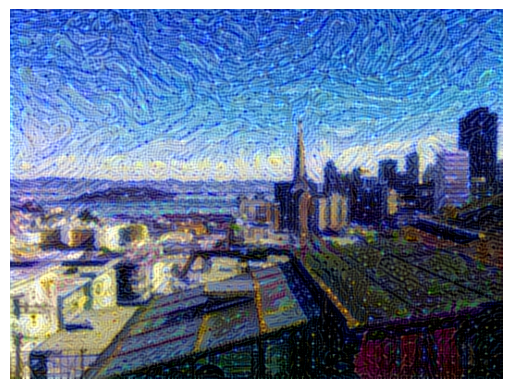

In [14]:
plt.axis("off")
plt.imshow(keras.utils.load_img("/content/drive/MyDrive/Colab Notebooks/NeuralStyleTransferoutputs/combination_image_at_iteration_4000.png"))